# 02 EDA and Label Analysis

processed **FakeHealth + healthfact** dataset and saves few quick analysis outputs


In [1]:
from pathlib import Path
import json

import pandas as pd


In [2]:
PROJECT_ROOT = Path(r'C:\Users\ribam\Desktop\Reseach\Dataset')
PROCESSED_PATH = PROJECT_ROOT / 'dataset' / 'processed' / 'fakehealth_healthfact_binary_clean.csv'
OUTPUT_DIR = PROJECT_ROOT / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_PATH


WindowsPath('C:/Users/ribam/Desktop/Reseach/Dataset/dataset/processed/fakehealth_healthfact_binary_clean.csv')

In [3]:
df = pd.read_csv(PROCESSED_PATH)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head(3)


Shape: (12273, 16)
Columns: ['dataset', 'split', 'record_id', 'text_kind', 'title', 'text', 'model_text', 'url', 'source', 'publish_date', 'label_original', 'label_binary', 'label', 'text_length_chars', 'text_length_words', 'model_text_length_words']


,dataset,split,record_id,text_kind,title,text,model_text,url,source,publish_date,label_original,label_binary,label,text_length_chars,text_length_words,model_text_length_words
0,fakehealth,release,news_reviews_00000,article_text,Tiny implantable device short-circuits hunger ...,"MADISON, Wis. -- More than 700 million adults ...",Tiny implantable device short-circuits hunger ...,https://web.archive.org/web/20181218015531/htt...,https://web.archive.org,1.546060e+09,2,0,0,3615,553,562
1,fakehealth,release,news_reviews_00001,article_text,Scientists report CRISPR restores effectivenes...,"Wilmington, DE, December 17, 2018 - The CRISPR...",Scientists report CRISPR restores effectivenes...,https://web.archive.org/web/20181217203805/htt...,https://web.archive.org,1.546060e+09,3,1,1,7022,1136,1145
2,fakehealth,release,news_reviews_00002,article_text,Probiotics could help millions of patients suf...,About 3 million people in the US are diagnosed...,Probiotics could help millions of patients suf...,https://web.archive.org/web/20181213085845/htt...,https://web.archive.org,1.546060e+09,1,0,0,2967,453,463


In [4]:
overall_label_counts = df['label_binary'].value_counts().sort_index()
dataset_label_counts = df.groupby(['dataset', 'label_binary']).size().unstack(fill_value=0)
split_counts = df['split'].value_counts(dropna=False)

display(overall_label_counts)
display(dataset_label_counts)
display(split_counts)


label_binary
0    4710
1    7563
Name: count, dtype: int64

label_binary,0,1
dataset,,
curated_health_claims,21,21
fakehealth,920,1236
healthfact,3769,6306


split
train      8109
story      1564
dev        1015
test        993
release     592
Name: count, dtype: int64

In [5]:
text_stats = df.groupby('dataset')[['text_length_chars', 'text_length_words']].agg(['mean', 'median', 'min', 'max'])
text_stats


text_length_chars                     text_length_words  \
                                   mean  median  min    max              mean   
dataset                                                                         
curated_health_claims         57.119048    56.0   30     85          8.619048   
fakehealth                  4194.373840  3970.5  102  29247        667.769481   
healthfact                    82.715931    65.0   26    435         13.112754   

                                        
                      median min   max  
dataset                                 
curated_health_claims    8.5   4    13  
fakehealth             628.0  18  4275  
healthfact              10.0   3    82

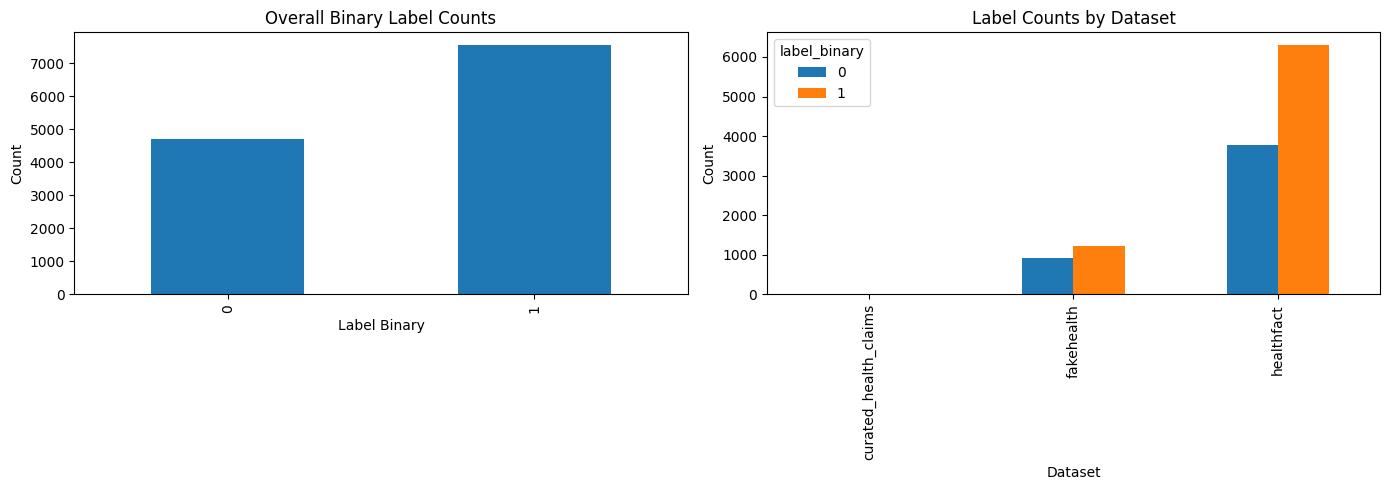

In [6]:
import os
MPLCONFIGDIR = OUTPUT_DIR / '.matplotlib'
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(MPLCONFIGDIR)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
overall_label_counts.plot(kind='bar', ax=axes[0], title='Overall Binary Label Counts')
axes[0].set_xlabel('Label Binary')
axes[0].set_ylabel('Count')

dataset_label_counts.plot(kind='bar', ax=axes[1], title='Label Counts by Dataset')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


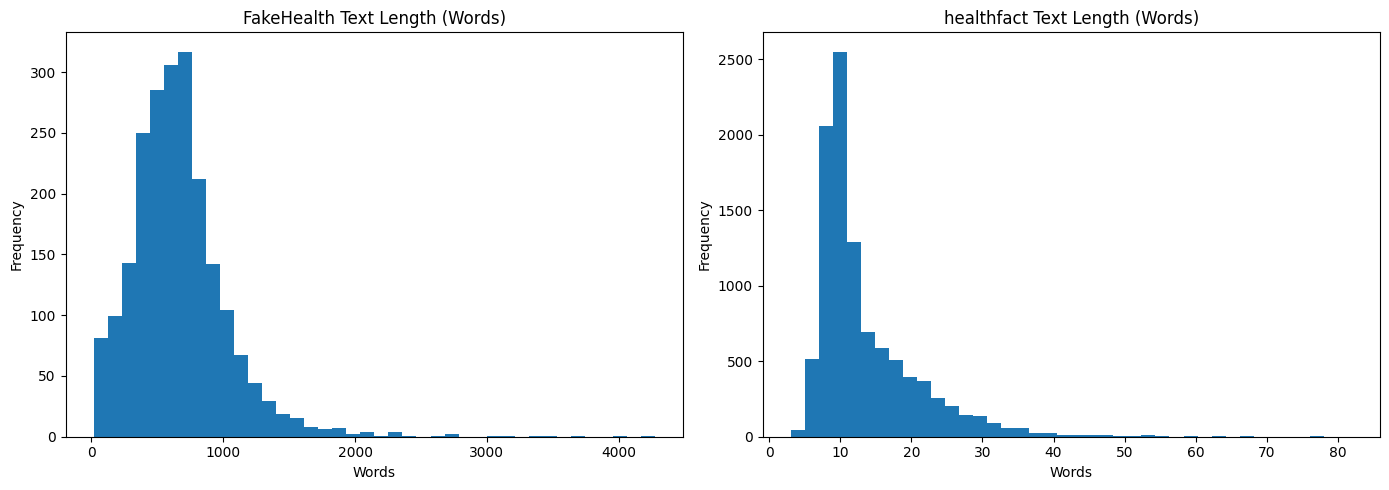

In [7]:
import os
MPLCONFIGDIR = OUTPUT_DIR / '.matplotlib'
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(MPLCONFIGDIR)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df[df['dataset'] == 'fakehealth']['text_length_words'].plot(kind='hist', bins=40, ax=axes[0], title='FakeHealth Text Length (Words)')
axes[0].set_xlabel('Words')

df[df['dataset'] == 'healthfact']['text_length_words'].plot(kind='hist', bins=40, ax=axes[1], title='healthfact Text Length (Words)')
axes[1].set_xlabel('Words')
plt.tight_layout()
plt.show()


In [8]:
eda_summary = {
    'rows': int(len(df)),
    'dataset_counts': df['dataset'].value_counts().to_dict(),
    'label_counts': df['label_binary'].value_counts().to_dict(),
    'split_counts': df['split'].value_counts(dropna=False).to_dict(),
    'avg_words_by_dataset': df.groupby('dataset')['text_length_words'].mean().round(2).to_dict(),
}

dataset_label_counts.to_csv(OUTPUT_DIR / 'eda_dataset_label_counts.csv')
text_stats.to_csv(OUTPUT_DIR / 'eda_text_stats.csv')
(OUTPUT_DIR / 'eda_summary.json').write_text(json.dumps(eda_summary, indent=2), encoding='utf-8')

print('Saved EDA outputs to:', OUTPUT_DIR)
eda_summary


Saved EDA outputs to: C:\Users\ribam\Desktop\Reseach\Dataset\output


{'rows': 12273,
 'dataset_counts': {'healthfact': 10075,
  'fakehealth': 2156,
  'curated_health_claims': 42},
 'label_counts': {1: 7563, 0: 4710},
 'split_counts': {'train': 8109,
  'story': 1564,
  'dev': 1015,
  'test': 993,
  'release': 592},
 'avg_words_by_dataset': {'curated_health_claims': 8.62,
  'fakehealth': 667.77,
  'healthfact': 13.11}}